In [1]:
# ============================================================
# F6 — Week 05 Black-Box Optimisation (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# ---------------------------
# Imports (all at top)
# ---------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import pairwise_distances

from scipy.stats import norm

In [2]:
# ============================================================
# 0) CONFIG
# ============================================================
warnings.filterwarnings("ignore", category=UserWarning)

# Your requested paths (course repo style)
INPUTS_PATH = "data/F6/initial_inputs.npy"
OUTPUTS_PATH = "data/F6/initial_outputs.npy"

# Fallback paths (works in this environment if the above don't exist)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Optimisation goal
GOAL = "MAXIMISE"  # (scores are negative; "better" is closer to 0 => larger value)

# Acquisition settings
XI = 0.01                   # EI exploration parameter
N_CANDIDATES = 200_000      # random candidate pool size
MIN_DIST = 0.02             # avoid near-duplicates (L2 distance threshold)

# Optional "ridge probing" constraint (matches your Week 04 plan)
USE_RIDGE_CONSTRAINT = True
RIDGE_X4_MIN = 0.95
RIDGE_X5_MAX = 0.03

RANDOM_SEED = 0

In [3]:
# ============================================================
# 1) LOAD
# ============================================================
def resolve_path(primary: str, fallback: str) -> str:
    if os.path.exists(primary):
        return primary
    if os.path.exists(fallback):
        return fallback
    raise FileNotFoundError(f"Could not find either '{primary}' or '{fallback}'")

x_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(x_path)  # shape (n, 5)
y = np.load(y_path)  # shape (n,)

print("Loaded:")
print("  X:", X.shape, "from", x_path)
print("  y:", y.shape, "from", y_path)
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]   mean={y.mean():.4f}")
print(f"  best observed (max): {y.max():.4f}")

Loaded:
  X: (24, 5) from data/F6/initial_inputs.npy
  y: (24,) from data/F6/initial_outputs.npy
  y range: [-2.5712, -0.4959]   mean=-1.3711
  best observed (max): -0.4959


In [4]:
# ============================================================
# 2) SURROGATE
# ============================================================
# GP: Constant * RBF(ARD) + WhiteKernel
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED,
)

surrogate = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", gpr),
])

surrogate.fit(X, y)

# In-sample predictions for diagnostics
mu_train, std_train = surrogate.predict(X, return_std=True)
r2 = r2_score(y, mu_train)

print("\nSurrogate fitted:")
print("  R^2 (train):", round(r2, 4))
print("  Learned kernel:", surrogate.named_steps["gpr"].kernel_)


Surrogate fitted:
  R^2 (train): 0.9883
  Learned kernel: 1.54**2 * RBF(length_scale=[1.85, 2.93, 4.06, 3.5, 4.99]) + WhiteKernel(noise_level=0.0395)


In [5]:
# ============================================================
# 3) ACQUISITION (Expected Improvement, MAXIMISE)
# ============================================================
def expected_improvement(mu: np.ndarray, sigma: np.ndarray, best_y: float, xi: float = 0.01) -> np.ndarray:
    """
    EI for maximisation.
    imp = mu - best_y - xi
    EI = imp * Phi(Z) + sigma * phi(Z),  where Z = imp / sigma
    """
    imp = mu - best_y - xi
    with np.errstate(divide="warn", invalid="warn"):
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei

rng = np.random.default_rng(RANDOM_SEED)

# Candidate pool
C = rng.random((N_CANDIDATES, X.shape[1]))  # uniform in [0,1]^5

# Optional ridge constraint to probe x4 high, x5 low (per Week 04 plan)
if USE_RIDGE_CONSTRAINT:
    mask = (C[:, 3] >= RIDGE_X4_MIN) & (C[:, 4] <= RIDGE_X5_MAX)
    C = C[mask]
    if C.shape[0] < 50:
        # if too few points pass, relax (keep it robust)
        USE_RIDGE_CONSTRAINT = False
        C = rng.random((N_CANDIDATES, X.shape[1]))
        print("\nRidge constraint too restrictive; reverted to unconstrained candidate pool.")
    else:
        print(f"\nUsing ridge constraint: kept {C.shape[0]} candidates.")

# Remove near-duplicates
dmin = pairwise_distances(C, X).min(axis=1)
C = C[dmin > MIN_DIST]

# Predict on candidates
mu_c, std_c = surrogate.predict(C, return_std=True)
best_y = float(y.max())
ei = expected_improvement(mu_c, std_c, best_y=best_y, xi=XI)

best_idx = int(np.argmax(ei))
x_next = C[best_idx]
mu_next = float(mu_c[best_idx])
std_next = float(std_c[best_idx])
ei_next = float(ei[best_idx])

print("\nAcquisition (EI) selected:")
print("  x_next =", np.array2string(x_next, precision=8, separator=", "))
print(f"  predicted mu={mu_next:.4f}, std={std_next:.4f}, EI={ei_next:.4f}")


Using ridge constraint: kept 330 candidates.

Acquisition (EI) selected:
  x_next = [0.52690025, 0.36429914, 0.80869075, 0.96827352, 0.0011734 ]
  predicted mu=-0.4639, std=0.1464, EI=0.0701


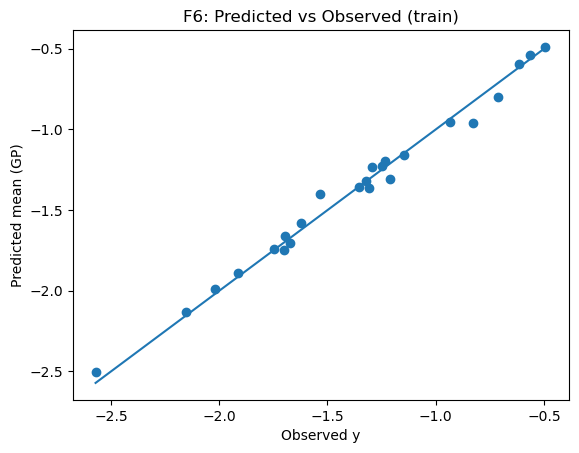

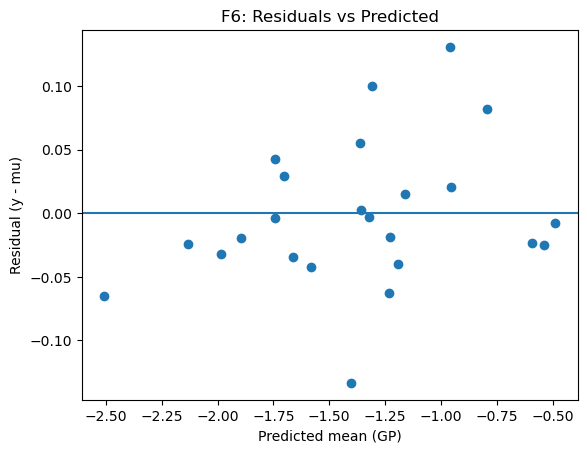

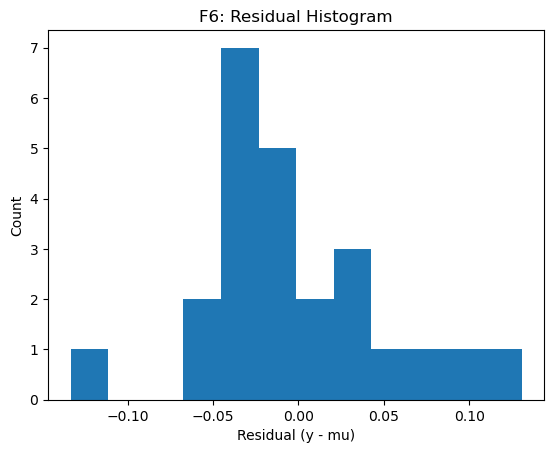

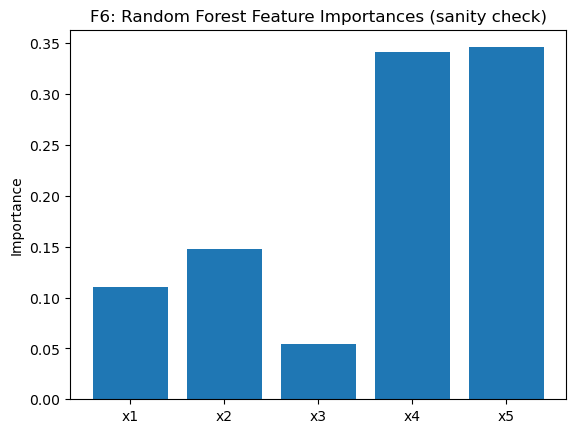

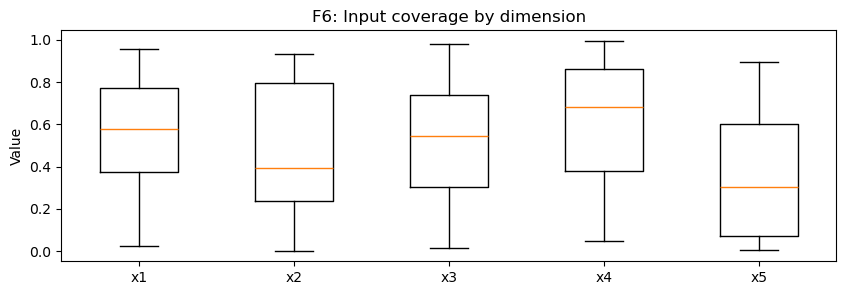


Exploration health:
  min L2 distance(x_next, X_existing) = 0.18871415194065715992266518696851562708616257


In [7]:
# ============================================================
# 4) DIAGNOSTICS
# ============================================================

# 4.1 Predicted mean vs observed
plt.figure()
plt.scatter(y, mu_train)
mn = min(y.min(), mu_train.min())
mx = max(y.max(), mu_train.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed y")
plt.ylabel("Predicted mean (GP)")
plt.title("F6: Predicted vs Observed (train)")
plt.show()

# 4.2 Residuals
resid = y - mu_train
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0)
plt.xlabel("Predicted mean (GP)")
plt.ylabel("Residual (y - mu)")
plt.title("F6: Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - mu)")
plt.ylabel("Count")
plt.title("F6: Residual Histogram")
plt.show()

# 4.3 Feature importance sanity check (RF)
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_SEED,
    min_samples_leaf=1,
)
rf.fit(X, y)
importances = rf.feature_importances_

plt.figure()
plt.bar(range(X.shape[1]), importances)
plt.xticks(range(X.shape[1]), [f"x{i+1}" for i in range(X.shape[1])])
plt.ylabel("Importance")
plt.title("F6: Random Forest Feature Importances (sanity check)")
plt.show()

# 4.4 Confirm not stuck: simple coverage plot (each dim)
plt.figure(figsize=(10, 3))
plt.boxplot(
    [X[:, j] for j in range(X.shape[1])],
    tick_labels=[f"x{j+1}" for j in range(X.shape[1])]
)
plt.title("F6: Input coverage by dimension")
plt.ylabel("Value")
plt.show()

# Distance of new point to existing samples (exploration health)
d_new = pairwise_distances(x_next.reshape(1, -1), X).min()
print(f"\nExploration health:")
print(f"  min L2 distance(x_next, X_existing) = {d_new:.44f}")


In [8]:
# ============================================================
# 5) OUTPUT (the one line you submit)
# ============================================================
# Print as one clean line (copy/paste)
print("\nSUBMIT THIS X (one row, 5 values):")
print(" ".join([f"{v:.8f}" for v in x_next]))


SUBMIT THIS X (one row, 5 values):
0.52690025 0.36429914 0.80869075 0.96827352 0.00117340
